处理数据样本的代码容易变得杂乱、难以维护。理想情况下，我们希望数据集代码与模型训练代码分开，以此提升可读性与模块化程度。

PyTorch 提供了两个数据原语：torch.utils.data.DataLoader 和 torch.utils.data.Dataset，既可以使用预加载数据集，也能加载自定义数据。
Dataset 用来存储样本以及对应的标签；DataLoader则在Dataset外面包装一层可迭代对象，方便我们读取样本。

PyTorch领域库内置了许多预加载数据集（例如 FashionMNIST），它们都是torch.utils.data.Dataset的子类，并实现了对应数据专属的功能，可用于模型原型开发与基准测试。相关资源可以在这里找到：图像数据集、文本数据集、音频数据集。

### PART1.数据集加载

下面演示如何从 TorchVision 加载 Fashion‑MNIST 数据集。Fashion‑MNIST 是 Zalando 服饰图片数据集，包含 60000 条训练样本、10000 条测试样本。每条样本为一张28×28灰度图片，附带10个类别中某一类的对应标签。

In [14]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
    #上一行的主要作用是将输入的图像数据（通常是 PIL Image 或 NumPy 数组）转换为 PyTorch 模型可以直接处理的标准化浮点数张量。
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

此处说明一下加载 FashionMNIST 数据集的参数：

root：训练集 / 测试集数据存放的文件路径

train：指定使用训练集还是测试集

download=True：如果root路径下找不到数据集，就从网上下载数据

transform 和 target_transform：分别指定对样本特征（图片）和标签做的变换预处理

### PART2.数据集的迭代与可视化

我们可以像操作列表一样，用索引手动访问 Dataset：training_data[index]。我们使用matplotlib来可视化训练集中的部分样本。

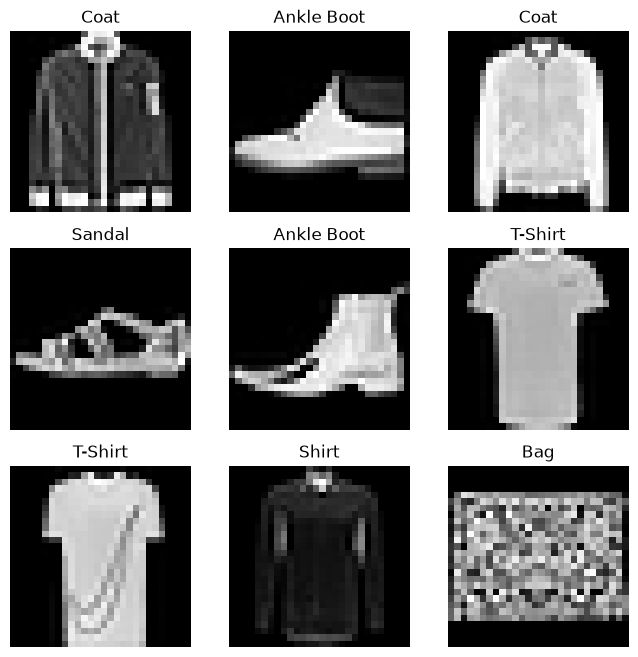

In [15]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item() # 随机选择一个样本
    img, label = training_data[sample_idx] # 获取样本和标签
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray") 
plt.show()

### PART3.自定义数据集

自定义 Dataset 类必须实现三个函数：__init__、__len__ 和 __getitem__。

请看下面的实现示例；FashionMNIST 的图片存放在 img_dir（图片文件夹），标签则单独保存在 CSV 文件 annotations_file（标注文件）中。

在接下来的小节，我们会逐个拆解每个函数内部做了什么。

In [16]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    '''
    __init__ 函数在实例化 Dataset 对象的时候只执行一次。我们在这里初始化图片所在文件夹路径、标注文件，
    以及各类图像变换 transform（下一小节会详细讲解）。labels.csv 文件内容示例如下：
    '''
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    '''
    __len__ 函数返回数据集当中样本的总数量。
    '''
    def __len__(self):
        return len(self.img_labels)

    '''
    __getitem__ 函数根据给定索引idx，加载并返回数据集中的一个样本。
    根据索引，找到磁盘上对应图片的路径，使用decode_image把图片转为张量；
    从self.img_labels的 CSV 表格中取出对应的标签；如果配置了 transform，就执行图像变换；
    最后以元组形式返回图像张量和对应的标签。
    '''
    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = decode_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

### PART4.使用 DataLoader 准备训练数据

Dataset 一次只能取出一个样本的特征与标签。但模型训练时，我们通常希望：

以小批次（minibatch）传入样本；
每一轮 epoch 结束后打乱数据，降低模型过拟合；
使用 Python 多进程来加速数据读取。

DataLoader 是一个可迭代对象，它把上面这些复杂逻辑封装成简单易用的接口。

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader  = DataLoader(test_data, batch_size=64, shuffle=True)

### PART5.遍历Dataloader

我们已经把数据集装入 DataLoader，可以按需迭代读取。每一轮迭代会返回一个批次的train_features和train_labels，分别包含 64 组特征与标签。
因为设置了shuffle=True，完整遍历完所有批次之后，数据顺序会被打乱。如果想要更加精细地控制数据读取顺序，可以查阅 Sampler（采样器）相关内容。

训练集的一个批次样本：: torch.Size([64, 1, 28, 28])
训练集的一个批次标签：: torch.Size([64])


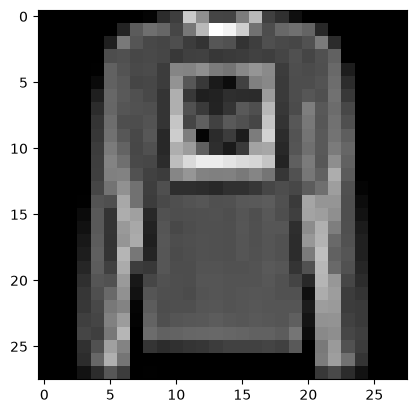

Label: 2


In [20]:
# 展示训练集的一个批次样本
train_features, train_labels = next(iter(train_dataloader))
print(f"训练集的一个批次样本：: {train_features.size()}")
print(f"训练集的一个批次标签：: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")